In [1]:
# load this dataset and show its columns: yt_videos_with_local_transcripts.parquet
import pandas as pd
# Load the dataset
file_path = r"D:\showreel\reza\Data_Cleaned\yt_videos_with_local_transcripts.parquet"
df = pd.read_parquet(file_path)
# Show the columns of the dataset
print(df.columns)

Index(['thumbnail_default_url', 'videoId', 'publishedAt', 'channelId',
       'channelTitle', 'title', 'description', 'tags', 'categoryId',
       'defaultLanguage', 'defaultAudioLanguage', 'definition', 'caption',
       'licensedContent', 'regionRestriction_blocked', 'license', 'embeddable',
       'madeForKids', 'viewCount', 'likeCount', 'commentCount', 'is_short',
       'is_hd', 'topic_labels_extracted', 'duration_seconds',
       'thumbnail_maxres_url', 'thumbnail_high_url', 'transcript',
       'local_transcript'],
      dtype='str')


In [ ]:
import matplotlib.pyplot as plt

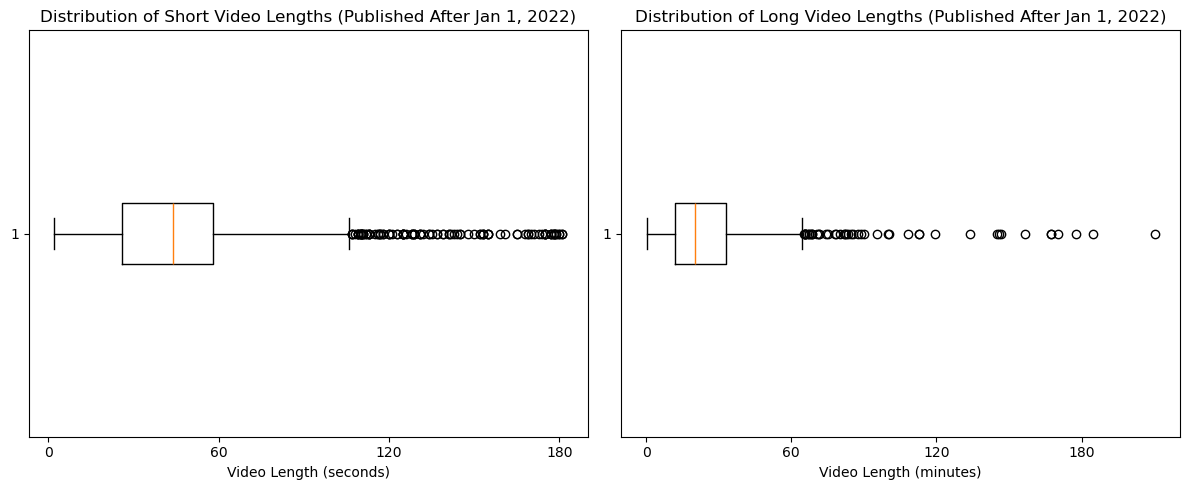

In [ ]:
# do the same but filter videos for the 'is_short' column and plot two graphs one for each value of 'is_short'
import pandas as pd
import matplotlib.pyplot as plt
# Reload the parquet so this cell does not depend on stale notebook state
boxplot_df = pd.read_parquet(file_path)
boxplot_df = boxplot_df[boxplot_df['publishedAt'] > '2022-01-01']
short_videos = boxplot_df[boxplot_df['is_short'] == True]
long_videos = boxplot_df[boxplot_df['is_short'] == False]
# Plot for short videos
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.boxplot(short_videos['duration_seconds'], vert=False)
plt.xlabel('Video Length (seconds)')
plt.xticks(ticks=range(0, int(short_videos['duration_seconds'].max()) + 1, 60))
plt.title('Distribution of Short Video Lengths (Published After Jan 1, 2022)')
# Plot for long videos; the unit of measurement should be minutes, and markers on the horizontal axis should be on 60, 120, 180, etc. (multiples of 60)
plt.subplot(1, 2, 2)
plt.boxplot(long_videos['duration_seconds']/60, vert=False)
plt.xlabel('Video Length (minutes)')
plt.title('Distribution of Long Video Lengths (Published After Jan 1, 2022)')
plt.xticks(ticks=range(0, int(long_videos['duration_seconds'].max()/60) + 1, 60))
plt.tight_layout()
plt.show()

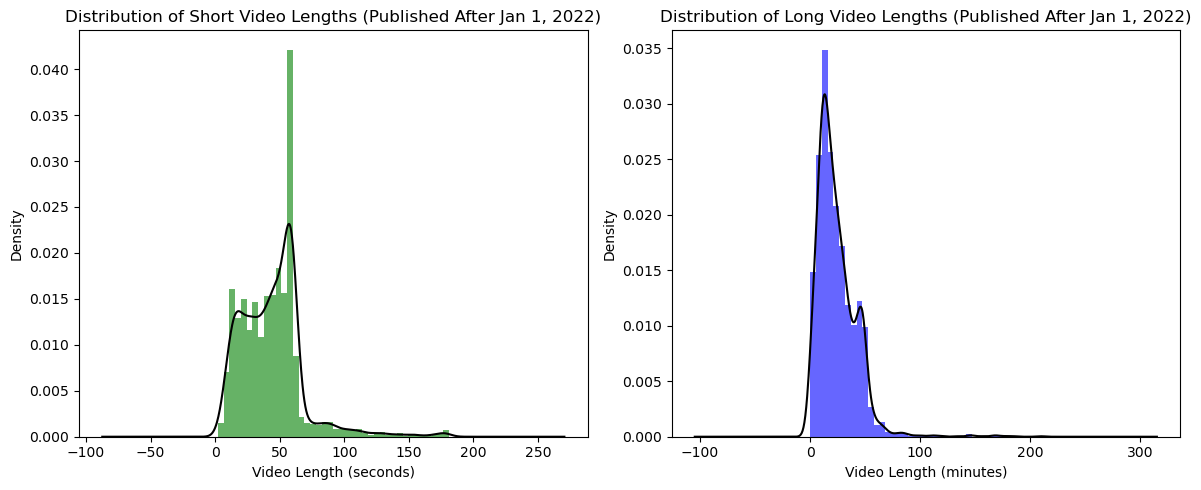

In [ ]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
short_videos['duration_seconds'].plot(kind='hist', bins=40, density=True, alpha=0.6, color='g')
short_videos['duration_seconds'].plot(kind='kde', color='black')
plt.xlabel('Video Length (seconds)')
plt.title('Distribution of Short Video Lengths (Published After Jan 1, 2022)')
plt.subplot(1, 2, 2)
(long_videos['duration_seconds']/60).plot(kind='hist', bins=40, density=True, alpha=0.6, color='b')
(long_videos['duration_seconds']/60).plot(kind='kde', color='black')
plt.xlabel('Video Length (minutes)')
plt.title('Distribution of Long Video Lengths (Published After Jan 1, 2022)')
plt.tight_layout()
plt.show()

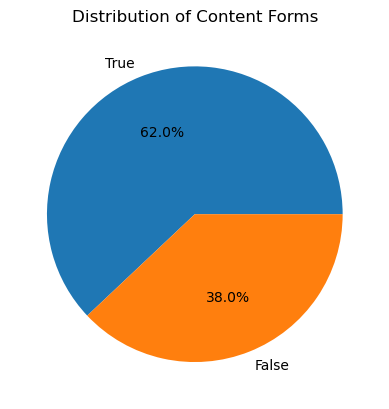

In [ ]:
# show the distribution of content form for the videos in this dataset, using a pie chart. The content form is in the 'is_short' column.
import pandas as pd
import matplotlib.pyplot as plt

content_distribution = boxplot_df['is_short'].value_counts()
plt.pie(content_distribution.values, labels=content_distribution.index, autopct='%1.1f%%')
plt.title('Distribution of Content Forms')
plt.show()

Total videos since 2022: 6577
  Short videos: 4080
  Long videos: 2497



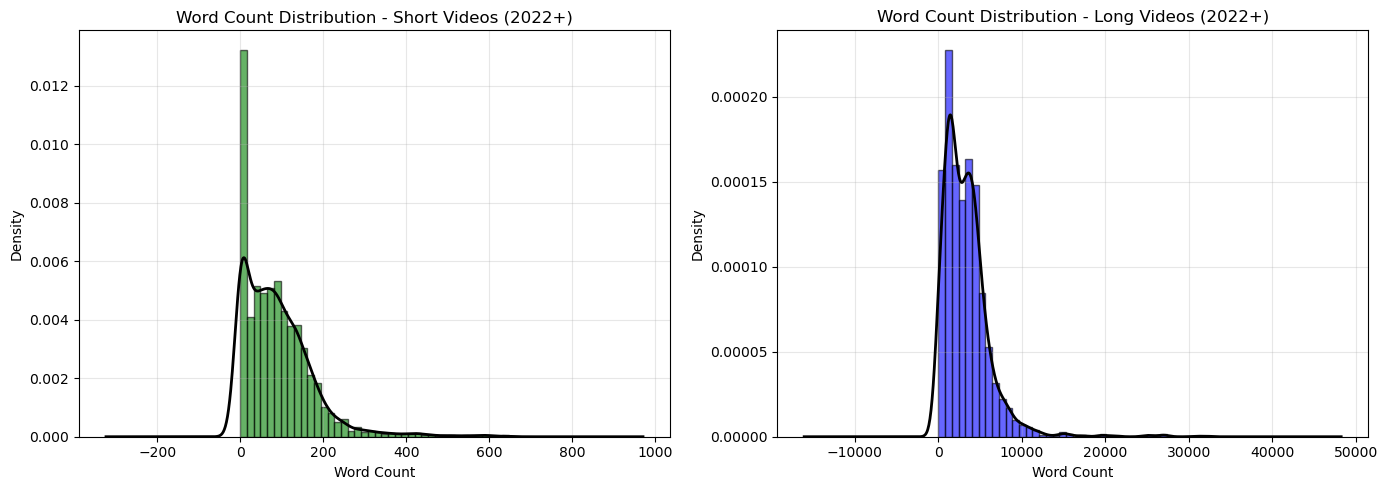


Short Videos - Word Count Statistics:
count    4080.000000
mean       89.887500
std        85.609279
min         0.000000
25%        25.000000
50%        75.000000
75%       131.000000
max       647.000000
Name: word_count, dtype: float64

Long Videos - Word Count Statistics:
count     2497.000000
mean      3311.532639
std       2905.100098
min          0.000000
25%       1367.000000
50%       2891.000000
75%       4463.000000
max      32166.000000
Name: word_count, dtype: float64


Error: : 
[1;31mThe Kernel crashed while executing code in the current cell or a previous cell. 

[1;31mPlease review the code in the cell(s) to identify a possible cause of the failure. 

[1;31mClick <a href='https://aka.ms/vscodeJupyterKernelCrash'>here</a> for more info. 

[1;31mView Jupyter <a href='command:jupyter.viewOutput'>log</a> for further details.

In [ ]:
# Filter videos from 2022 onwards
df_2022_onwards = df[df['publishedAt'] > '2022-01-01'].copy()

# Calculate word count for each transcript
df_2022_onwards['word_count'] = df_2022_onwards['local_transcript'].fillna('').str.split().str.len()

# Split by form (short vs long)
shorts_2022 = df_2022_onwards[df_2022_onwards['is_short'] == True]
longs_2022 = df_2022_onwards[df_2022_onwards['is_short'] == False]

print(f"Total videos since 2022: {len(df_2022_onwards)}")
print(f"  Short videos: {len(shorts_2022)}")
print(f"  Long videos: {len(longs_2022)}\n")

# Plot word count distribution for each category
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
shorts_2022['word_count'].plot(kind='hist', bins=40, density=True, alpha=0.6, color='g', edgecolor='black')
shorts_2022['word_count'].plot(kind='kde', color='black', linewidth=2)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Word Count Distribution - Short Videos (2022+)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
longs_2022['word_count'].plot(kind='hist', bins=40, density=True, alpha=0.6, color='b', edgecolor='black')
longs_2022['word_count'].plot(kind='kde', color='black', linewidth=2)
plt.xlabel('Word Count')
plt.ylabel('Density')
plt.title('Word Count Distribution - Long Videos (2022+)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nShort Videos - Word Count Statistics:")
print(shorts_2022['word_count'].describe())
print(f"\nLong Videos - Word Count Statistics:")
print(longs_2022['word_count'].describe())

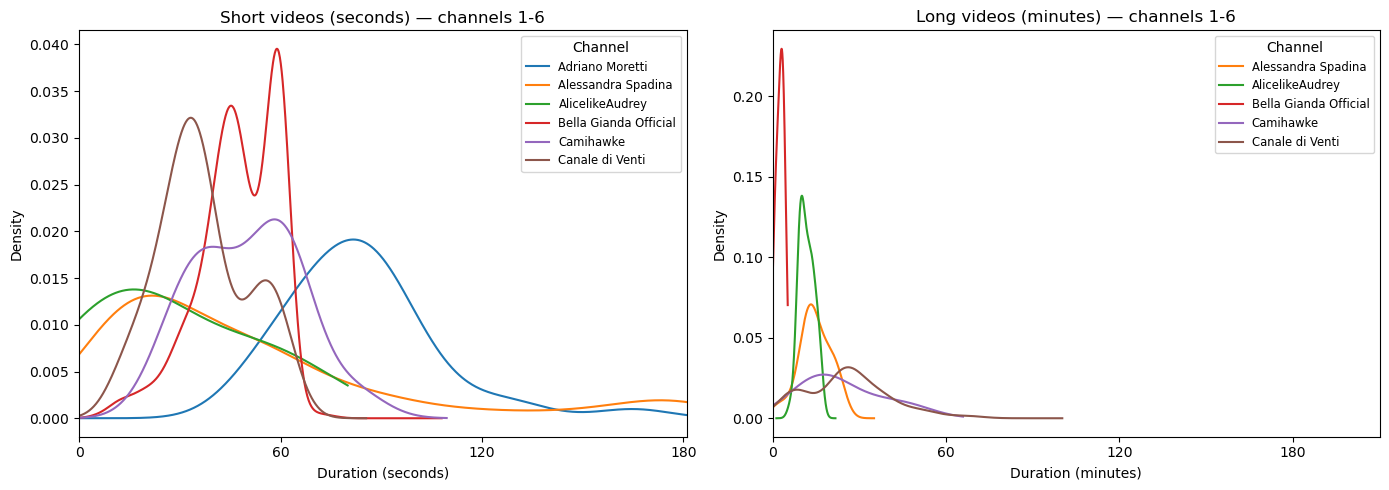

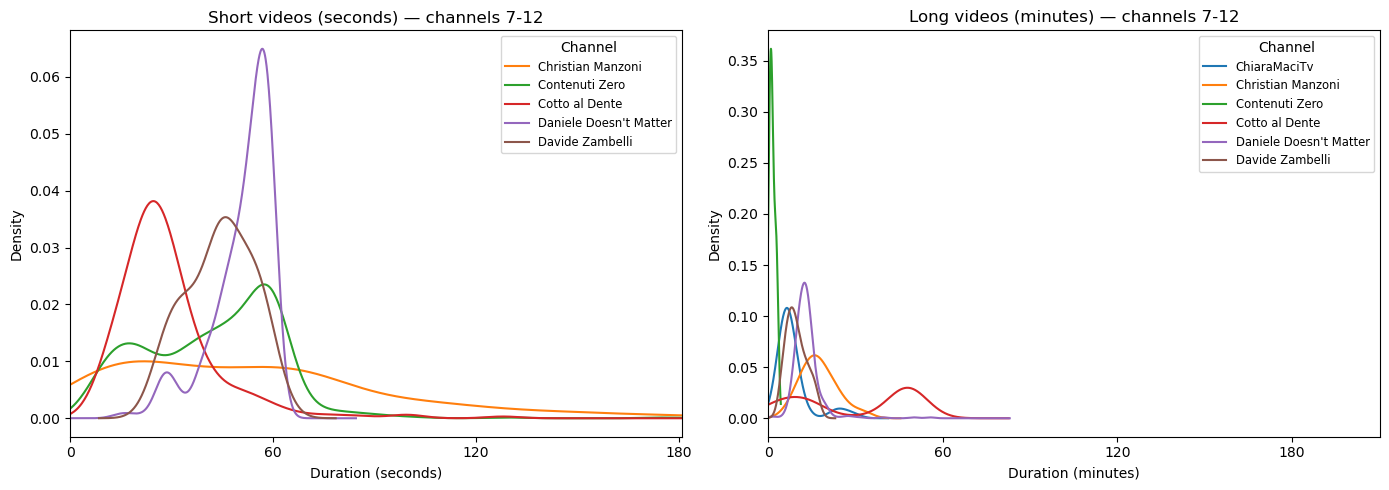

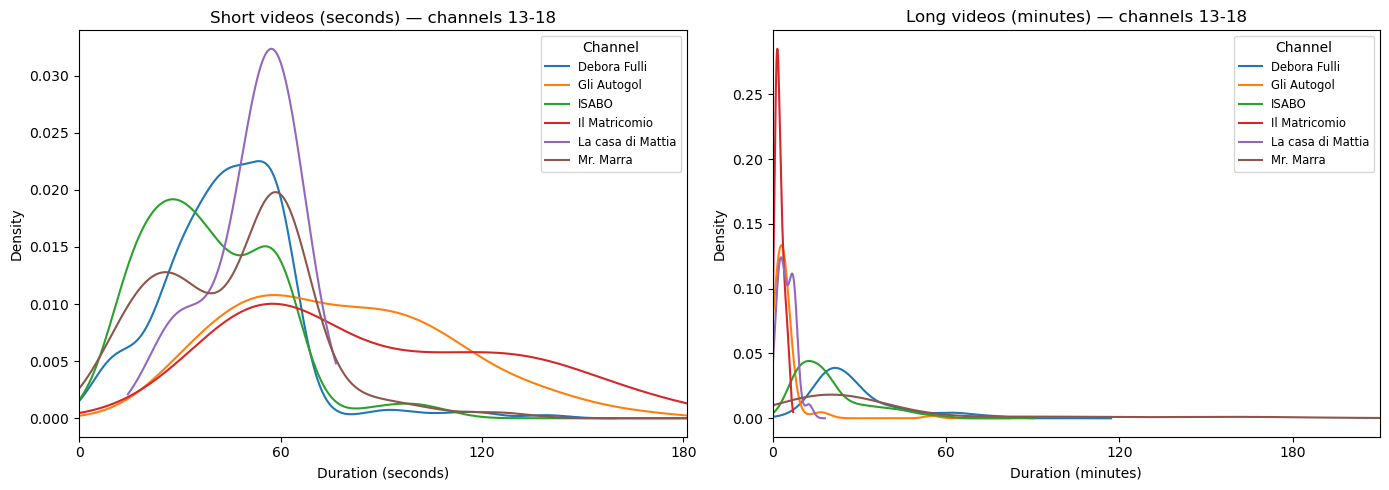

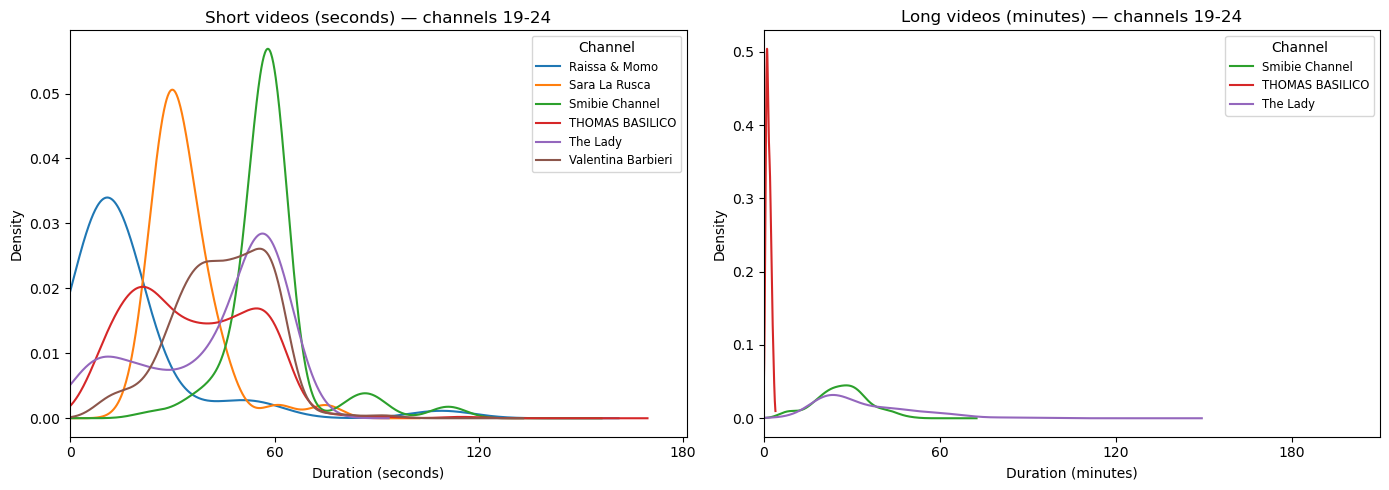

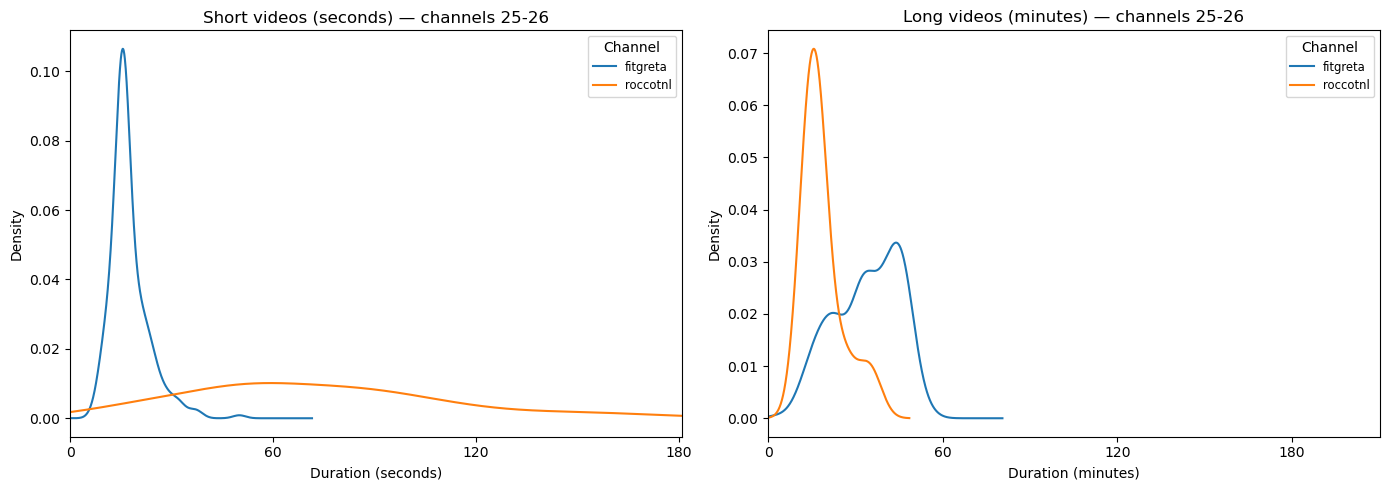

In [ ]:
# helper to split an iterable into chunks of given size
def chunks(iterable, size):
    it = list(iterable)
    for i in range(0, len(it), size):
        yield it[i:i+size]

# KDE rows with a minimum threshold of 3 videos per channel-format
min_videos = 3

analysis_df = df[df['publishedAt'] > '2022-01-01'].copy()
subset_short = analysis_df[analysis_df['is_short'] == True]
subset_long = analysis_df[analysis_df['is_short'] == False]

channel_format_counts = (
    analysis_df.groupby(['channelTitle', 'is_short'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: 'short_count', False: 'long_count'})
)

channels = [
    ch for ch, row in channel_format_counts.iterrows()
    if row.get('short_count', 0) >= min_videos or row.get('long_count', 0) >= min_videos
]

chunk_size = 6

xlim_short = (0, float(subset_short['duration_seconds'].dropna().max()))
xlim_long = (0, float((subset_long['duration_seconds'].dropna() / 60).max()))

ticks_short = range(0, int(xlim_short[1]) + 1, 60)
ticks_long = range(0, int(xlim_long[1]) + 1, 60)

for i, ch_chunk in enumerate(chunks(channels, chunk_size)):
    if not ch_chunk:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ch, c in zip(ch_chunk, plt.cm.tab10(range(len(ch_chunk)))):
        s_short = subset_short.loc[subset_short['channelTitle'] == ch, 'duration_seconds'].dropna()
        s_long = (subset_long.loc[subset_long['channelTitle'] == ch, 'duration_seconds'].dropna() / 60)

        if len(s_short) >= min_videos:
            s_short.plot(kind='kde', ax=axes[0], color=c, label=ch, linewidth=1.5)

        if len(s_long) >= min_videos:
            s_long.plot(kind='kde', ax=axes[1], color=c, label=ch, linewidth=1.5)

    start_idx = i * chunk_size + 1
    end_idx = i * chunk_size + len(ch_chunk)

    axes[0].set_title(f"Short videos (seconds) — channels {start_idx}-{end_idx}")
    axes[1].set_title(f"Long videos (minutes) — channels {start_idx}-{end_idx}")
    axes[0].set_xlabel('Duration (seconds)')
    axes[1].set_xlabel('Duration (minutes)')

    axes[0].set_xlim(xlim_short)
    axes[0].set_xticks(ticks_short)
    axes[1].set_xlim(xlim_long)
    axes[1].set_xticks(ticks_long)

    if axes[0].lines:
        axes[0].legend(title='Channel', fontsize='small', loc='best')
    if axes[1].lines:
        axes[1].legend(title='Channel', fontsize='small', loc='best')

    plt.tight_layout()
    plt.show()

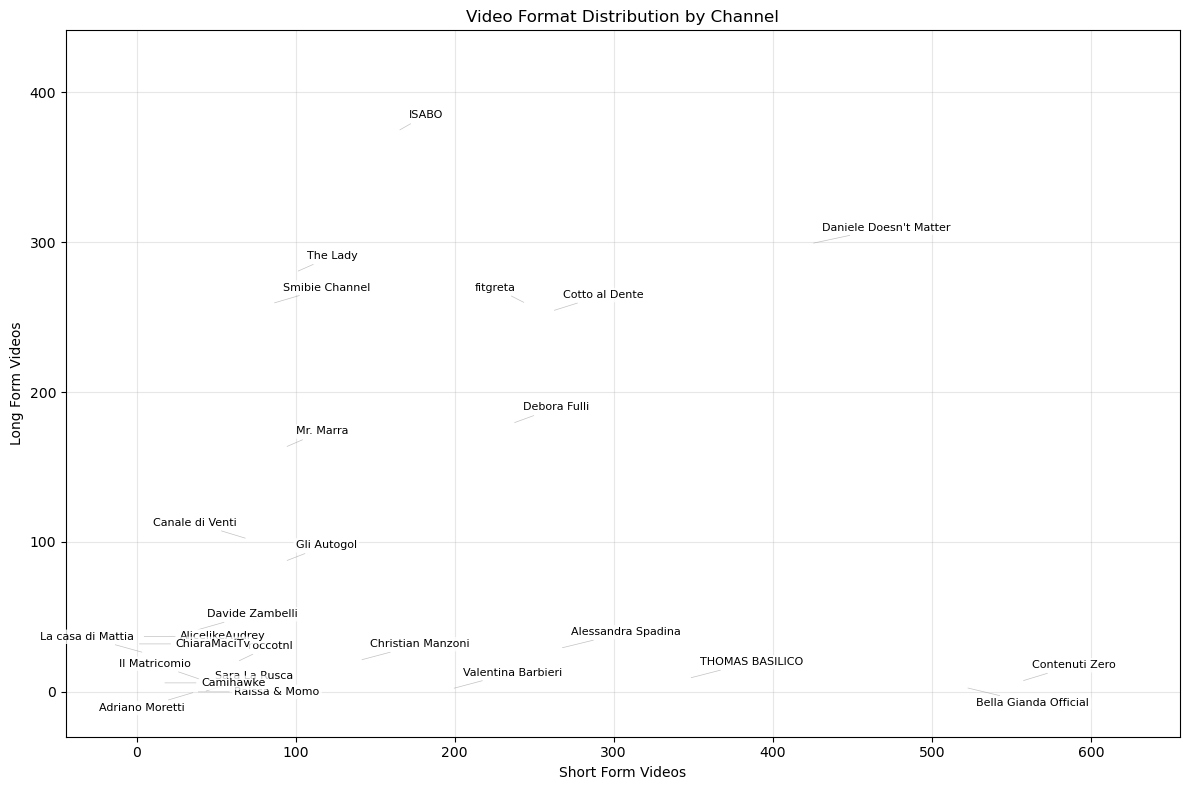

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plot_df = channel_format_counts.copy().sort_values(['short_count', 'long_count'], ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))

x_vals = plot_df['short_count'].astype(float).to_numpy()
y_vals = plot_df['long_count'].astype(float).to_numpy()

x_min, x_max = float(np.min(x_vals)), float(np.max(x_vals))
y_min, y_max = float(np.min(y_vals)), float(np.max(y_vals))

x_span = max(x_max - x_min, 1.0)
y_span = max(y_max - y_min, 1.0)

ax.set_xlim(x_min - x_span * 0.08, x_max + x_span * 0.18)
ax.set_ylim(y_min - y_span * 0.08, y_max + y_span * 0.18)

candidate_offsets = [
    (8, 8), (8, -8), (-8, 8), (-8, -8),
    (14, 0), (-14, 0), (0, 14), (0, -14),
    (18, 12), (-18, 12), (18, -12), (-18, -12),
    (24, 0), (0, 24), (-24, 0), (0, -24),
]

placed_bboxes = []
renderer = None

for channel_name, row in plot_df.iterrows():
    x = float(row['short_count'])
    y = float(row['long_count'])

    for dx, dy in candidate_offsets:
        text = ax.annotate(
            channel_name,
            (x, y),
            xytext=(dx, dy),
            textcoords='offset points',
            ha='left' if dx >= 0 else 'right',
            va='bottom' if dy >= 0 else 'top',
            fontsize=8,
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                edgecolor='none',
                alpha=0.8,
            ),
            arrowprops=dict(arrowstyle='-', color='0.6', lw=0.5, alpha=0.6),
        )

        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        bbox = text.get_window_extent(renderer=renderer).expanded(1.05, 1.1)

        if not any(bbox.overlaps(existing) for existing in placed_bboxes):
            placed_bboxes.append(bbox)
            break

        text.remove()
    else:
        text = ax.annotate(
            channel_name,
            (x, y),
            xytext=(28, 0),
            textcoords='offset points',
            ha='left',
            va='center',
            fontsize=8,
            bbox=dict(
                boxstyle='round,pad=0.2',
                facecolor='white',
                edgecolor='none',
                alpha=0.8,
            ),
            arrowprops=dict(arrowstyle='-', color='0.6', lw=0.5, alpha=0.6),
        )
        fig.canvas.draw()
        renderer = fig.canvas.get_renderer()
        placed_bboxes.append(text.get_window_extent(renderer=renderer).expanded(1.05, 1.1))

ax.set_xlabel('Short Form Videos')
ax.set_ylabel('Long Form Videos')
ax.set_title('Video Format Distribution by Channel')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Comments

In [ ]:
# there are 4 comments dataset, load them and show their columns. their paths follow this pattern: yt_comments_*_cleaned.parquet
import glob
import pandas as pd

comments_files = glob.glob(r"D:\showreel\reza\Data_Cleaned\yt_comments_*_cleaned.parquet")

for file_path in comments_files:
    df = pd.read_parquet(file_path)
    print(f"Columns in {file_path}:")
    print(df.columns.tolist())
    print()

Columns in D:\showreel\reza\Data_Cleaned\yt_comments_1_cleaned.parquet:
['threadId', 'commentId', 'videoId', 'canReply', 'channelId', 'authorChannelId', 'textOriginal', 'likeCount', 'viewerRating', 'canRate', 'publishedAt', 'updatedAt', 'totalReplyCount', 'isReply']

Columns in D:\showreel\reza\Data_Cleaned\yt_comments_2_cleaned.parquet:
['threadId', 'commentId', 'videoId', 'canReply', 'channelId', 'authorChannelId', 'textOriginal', 'likeCount', 'viewerRating', 'canRate', 'publishedAt', 'updatedAt', 'totalReplyCount', 'isReply']

Columns in D:\showreel\reza\Data_Cleaned\yt_comments_3_cleaned.parquet:
['threadId', 'commentId', 'videoId', 'canReply', 'channelId', 'authorChannelId', 'textOriginal', 'likeCount', 'viewerRating', 'canRate', 'publishedAt', 'updatedAt', 'totalReplyCount', 'isReply']

Columns in D:\showreel\reza\Data_Cleaned\yt_comments_4_cleaned.parquet:
['threadId', 'commentId', 'videoId', 'canReply', 'channelId', 'authorChannelId', 'textOriginal', 'likeCount', 'viewerRating'

In [ ]:
from pathlib import Path
import numpy as np

analysis_start = pd.to_datetime("2022-01-01 12:00:00")

comments=pd.concat((pd.read_parquet(p) for p in comments_files), ignore_index=True)

# --- prepare dates and join comments -> video publish date ---
video_pub = df[['videoId', 'publishedAt']].drop_duplicates().copy()
video_pub['publishedAt'] = pd.to_datetime(video_pub['publishedAt'])

comments_work = comments[['videoId', 'updatedAt']].copy()
comments_work['updatedAt'] = pd.to_datetime(comments_work['updatedAt'])

# Avoid a many-to-many merge explosion: keep exactly one publish date per videoId
video_pub_unique = (
    video_pub.dropna(subset=['videoId', 'publishedAt'])
    .sort_values('publishedAt')
    .drop_duplicates(subset='videoId', keep='first')
)

merged = comments_work.merge(
    video_pub_unique,
    on='videoId',
    how='inner',
    validate='many_to_one',
)

# condition:
# comment published >= analysis_start
# video published < analysis_start

late_comments_on_old_videos = merged[
    (merged['updatedAt'] >= analysis_start.tz_localize('UTC')) &
    (merged['publishedAt'] < analysis_start.tz_localize('UTC'))
]

# denominator: all comments belonging to those videos
target_video_ids = late_comments_on_old_videos['videoId'].dropna().unique()
all_comments_for_target_videos = merged[merged['videoId'].isin(target_video_ids)]

num = len(late_comments_on_old_videos)
den = len(all_comments_for_target_videos)
pct = (num / den * 100) if den else 0.0

print(f"Analysis start date: {analysis_start.date()}")
print(f"Videos involved (published before start, with >=1 late comment): {len(target_video_ids):,}")
print(f"Comments after start on those pre-start videos: {num:,}")
print(f"Total comments on those videos (all dates): {den:,}")
print(f"Percentage: {pct:.2f}%")

Analysis start date: 2022-01-01
Videos involved (published before start, with >=1 late comment): 562
Comments after start on those pre-start videos: 9,282
Total comments on those videos (all dates): 269,606
Percentage: 3.44%


# Dataset Overview

In [ ]:
import pandas as pd
import numpy as np

VIDEO_FILE = r"D:\showreel\reza\Data_Cleaned\yt_videos_with_local_transcripts.parquet"
df_videos = pd.read_parquet(VIDEO_FILE)
df_videos['publishedAt'] = pd.to_datetime(df_videos['publishedAt'])
for col in ['viewCount', 'likeCount', 'commentCount', 'duration_seconds']:
    df_videos[col] = pd.to_numeric(df_videos[col], errors='coerce')

print("=== Dataset Overview ===")
print(f"Total videos         : {len(df_videos):,}")
print(f"Date range           : {df_videos['publishedAt'].min().date()} to {df_videos['publishedAt'].max().date()}")
print(f"Unique channel IDs   : {df_videos['channelId'].nunique()}")
print(f"Unique channel names : {df_videos['channelTitle'].nunique()}")
print()
print(f"Short videos : {df_videos['is_short'].sum():,}  ({df_videos['is_short'].mean()*100:.1f}%)")
print(f"Long videos  : {(~df_videos['is_short']).sum():,}  ({(~df_videos['is_short']).mean()*100:.1f}%)")
print()
print("Transcript coverage:")
print(f"  transcript       : {df_videos['transcript'].notna().sum():,}  ({df_videos['transcript'].notna().mean()*100:.1f}%)")
print(f"  local_transcript : {df_videos['local_transcript'].notna().sum():,}  ({df_videos['local_transcript'].notna().mean()*100:.1f}%)")
print()
print("Null rates (columns with any missing data):")
null_pct = (df_videos.isnull().mean() * 100).sort_values(ascending=False)
for col, pct in null_pct[null_pct > 0].items():
    print(f"  {col:<40} {pct:.1f}%")

=== Dataset Overview ===
Total videos         : 12,829
Date range           : 2008-02-14 to 2026-03-01
Unique channel IDs   : 27
Unique channel names : 27

Short videos : 4,356  (34.0%)
Long videos  : 8,473  (66.0%)

Transcript coverage:
  transcript       : 12,829  (100.0%)
  local_transcript : 11,801  (92.0%)

Null rates (columns with any missing data):
  regionRestriction_blocked                97.4%
  tags                                     31.6%
  description                              25.1%
  thumbnail_maxres_url                     13.2%
  local_transcript                         8.0%
  topic_labels_extracted                   6.7%
  likeCount                                5.3%
  commentCount                             0.1%


# Publication Timeline

C:\Users\Mohammad Reza\AppData\Local\Temp\ipykernel_21620\126470955.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  pub['month'] = pub['publishedAt'].dt.to_period('M')


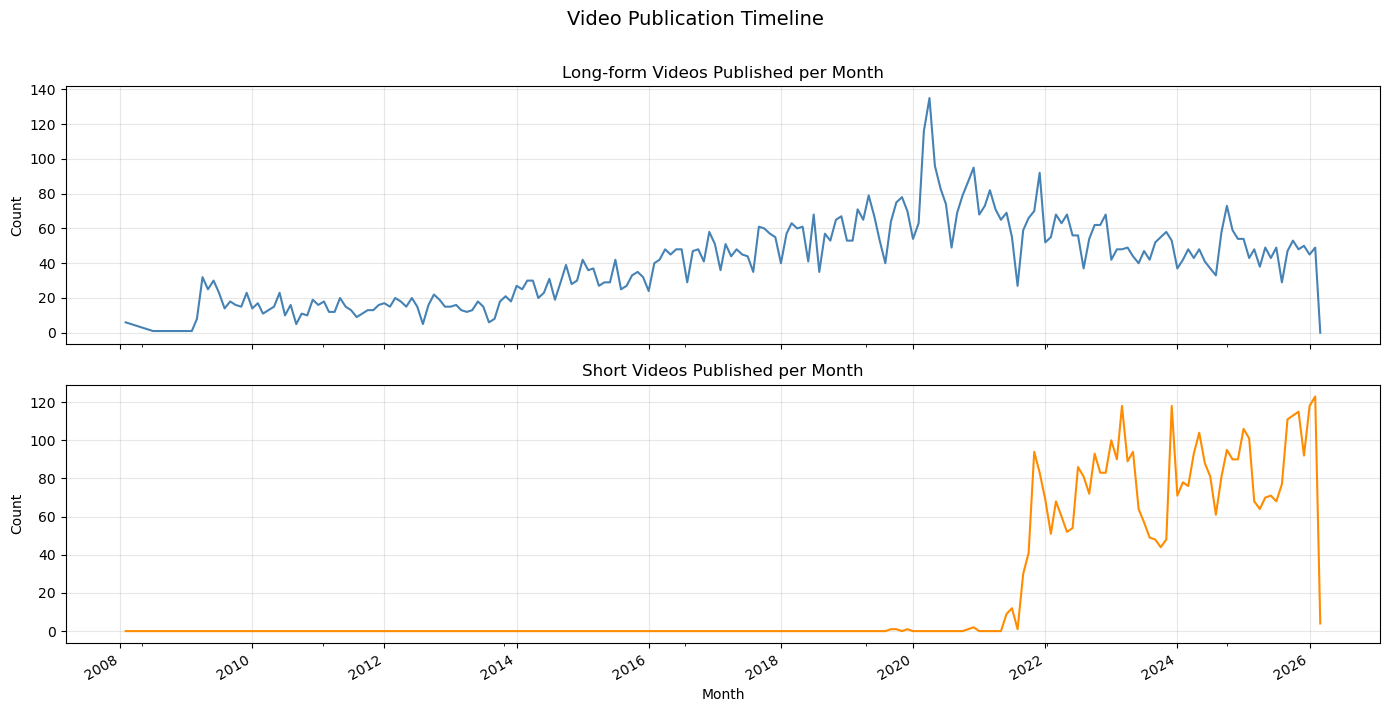

In [ ]:
import matplotlib.pyplot as plt

pub = df_videos[['publishedAt', 'is_short']].copy()
pub['month'] = pub['publishedAt'].dt.to_period('M')

monthly = (
    pub.groupby(['month', 'is_short'])
    .size()
    .unstack(fill_value=0)
    .rename(columns={True: 'Shorts', False: 'Long-form'})
)
monthly.index = monthly.index.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

monthly['Long-form'].plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Long-form Videos Published per Month')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

monthly['Shorts'].plot(ax=axes[1], color='darkorange', linewidth=1.5)
axes[1].set_title('Short Videos Published per Month')
axes[1].set_ylabel('Count')
axes[1].set_xlabel('Month')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Video Publication Timeline', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Engagement Metrics

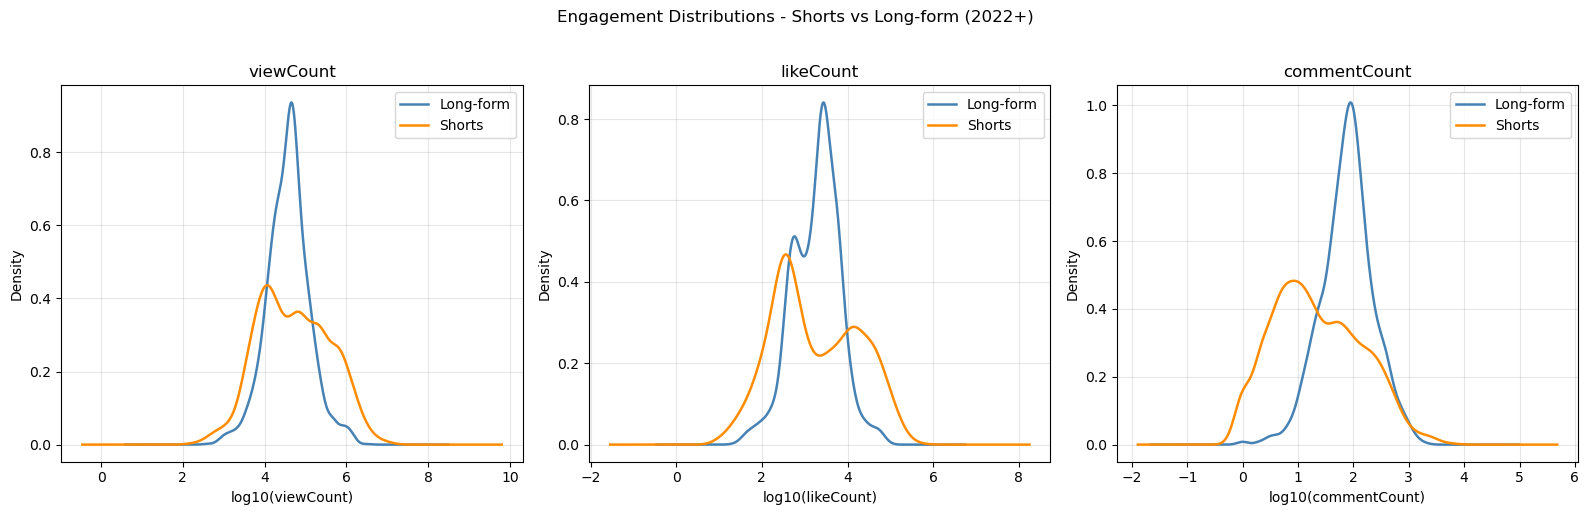


Median engagement (2022+):
  Long-form: viewCount=39,846  |  likeCount=2,224  |  commentCount=82
  Shorts: viewCount=47,469  |  likeCount=1,165  |  commentCount=16


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

eng = df_videos[df_videos['publishedAt'] >= '2022-01-01'].copy()
shorts_e = eng[eng['is_short'] == True]
longs_e  = eng[eng['is_short'] == False]

metrics = ['viewCount', 'likeCount', 'commentCount']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, metric in zip(axes, metrics):
    for subset, label, color in [(longs_e, 'Long-form', 'steelblue'),
                                  (shorts_e, 'Shorts', 'darkorange')]:
        vals = subset[metric].dropna()
        vals = vals[vals > 0]
        if len(vals) > 1:
            np.log10(vals).plot(kind='kde', ax=ax, label=label, color=color, linewidth=1.8)
    ax.set_xlabel(f'log10({metric})')
    ax.set_title(metric)
    ax.legend()
    ax.grid(True, alpha=0.3)

fig.suptitle('Engagement Distributions - Shorts vs Long-form (2022+)', y=1.02)
plt.tight_layout()
plt.show()

print("\nMedian engagement (2022+):")
for label, subset in [('Long-form', longs_e), ('Shorts', shorts_e)]:
    meds = subset[metrics].median()
    print(f"  {label}: " + "  |  ".join(f"{m}={meds[m]:,.0f}" for m in metrics))

In [ ]:
import matplotlib.pyplot as plt

corr_cols = ['viewCount', 'likeCount', 'commentCount', 'duration_seconds']
labels    = ['views', 'likes', 'comments', 'duration']

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

base = df_videos[df_videos['publishedAt'] >= '2022-01-01']
for ax, (title, mask) in zip(axes, [
    ('Long-form', ~base['is_short']),
    ('Shorts',     base['is_short']),
]):
    corr = base[mask][corr_cols].corr()
    im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1)
    ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, rotation=30, ha='right')
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(len(labels)):
        for j in range(len(labels)):
            v = corr.iloc[i, j]
            ax.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=10,
                    color='white' if abs(v) > 0.55 else 'black')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_title(f'Engagement Correlations - {title}')

plt.tight_layout()
plt.show()

In [ ]:
import matplotlib.pyplot as plt

base = df_videos[df_videos['publishedAt'] >= '2022-01-01']

def channel_stats(subset):
    return (
        subset.groupby('channelTitle')
        .agg(
            videos          = ('videoId',      'count'),
            total_views     = ('viewCount',    'sum'),
            median_views    = ('viewCount',    'median'),
            median_likes    = ('likeCount',    'median'),
            median_comments = ('commentCount', 'median'),
        )
        .sort_values('total_views', ascending=False)
    )

ch_long  = channel_stats(base[~base['is_short']])
ch_short = channel_stats(base[ base['is_short']])

print("Top 10 channels by total views — Long-form (2022+):")
print(ch_long.head(10).to_string())
print("\nTop 10 channels by total views — Shorts (2022+):")
print(ch_short.head(10).to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ch_long['total_views'].head(10).sort_values().plot(
    kind='barh', ax=axes[0, 0], color='steelblue')
axes[0, 0].set_title('Long-form: Total Views — Top 10')
axes[0, 0].set_xlabel('Total Views')
axes[0, 0].grid(True, alpha=0.3)

ch_long['median_views'].sort_values(ascending=False).head(10).sort_values().plot(
    kind='barh', ax=axes[0, 1], color='cornflowerblue')
axes[0, 1].set_title('Long-form: Median Views per Video — Top 10')
axes[0, 1].set_xlabel('Median Views')
axes[0, 1].grid(True, alpha=0.3)

ch_short['total_views'].head(10).sort_values().plot(
    kind='barh', ax=axes[1, 0], color='darkorange')
axes[1, 0].set_title('Shorts: Total Views — Top 10')
axes[1, 0].set_xlabel('Total Views')
axes[1, 0].grid(True, alpha=0.3)

ch_short['median_views'].sort_values(ascending=False).head(10).sort_values().plot(
    kind='barh', ax=axes[1, 1], color='sandybrown')
axes[1, 1].set_title('Shorts: Median Views per Video — Top 10')
axes[1, 1].set_xlabel('Median Views')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Channel Engagement by Format (2022+)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Comments Analysis

In [ ]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

comments_files = glob.glob(r"D:\showreel\reza\Data_Cleaned\yt_comments_*_cleaned.parquet")
comments_all = pd.concat(
    (pd.read_parquet(p) for p in sorted(comments_files)), ignore_index=True
)
comments_all['likeCount']   = pd.to_numeric(comments_all['likeCount'], errors='coerce')
comments_all['publishedAt'] = pd.to_datetime(comments_all['publishedAt'])

print("=== Comments Overview ===")
print(f"Total comments  : {len(comments_all):,}")
print(f"Unique videos   : {comments_all['videoId'].nunique():,}")
print(f"Unique channels : {comments_all['channelId'].nunique():,}")
print(f"Top-level       : {(~comments_all['isReply']).sum():,}  ({(~comments_all['isReply']).mean()*100:.1f}%)")
print(f"Replies         : {comments_all['isReply'].sum():,}  ({comments_all['isReply'].mean()*100:.1f}%)")
print(f"Date range      : {comments_all['publishedAt'].min().date()} to {comments_all['publishedAt'].max().date()}")

cpv = comments_all.groupby('videoId').size()
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

log_cpv = np.log10(cpv[cpv > 0])
log_cpv.plot(kind='hist', bins=40, ax=axes[0], density=True,
             color='steelblue', edgecolor='black', alpha=0.7)
log_cpv.plot(kind='kde', ax=axes[0], color='black', linewidth=1.5)
axes[0].set_xlabel('log10(comments per video)')
axes[0].set_title('Comments per Video Distribution')
axes[0].grid(True, alpha=0.3)

liked = comments_all[comments_all['likeCount'] > 0]['likeCount']
log_liked = np.log10(liked)
log_liked.plot(kind='hist', bins=40, ax=axes[1], density=True,
               color='darkorange', edgecolor='black', alpha=0.7)
log_liked.plot(kind='kde', ax=axes[1], color='black', linewidth=1.5)
axes[1].set_xlabel('log10(comment likes)')
axes[1].set_title('Comment Like Count (non-zero only)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nComments per video - summary stats:")
print(cpv.describe().to_string())

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

monthly_c = comments_all.set_index('publishedAt').resample('ME')['commentId'].count()

fig, ax = plt.subplots(figsize=(14, 4))
monthly_c.plot(ax=ax, color='steelblue', linewidth=1.5)
ax.set_title('Comment Activity Over Time')
ax.set_xlabel('Month')
ax.set_ylabel('Comments per month')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

top_c = (
    comments_all.groupby('videoId').size()
    .sort_values(ascending=False).head(10)
    .reset_index(name='comment_count')
)
meta = df_videos[['videoId', 'title', 'channelTitle']].drop_duplicates('videoId')
top_c = top_c.merge(meta, on='videoId', how='left')

print("Top 10 most commented videos:")
for _, row in top_c.iterrows():
    title   = str(row.get('title',        'N/A'))[:55]
    channel = str(row.get('channelTitle', 'N/A'))[:22]
    count   = int(row['comment_count'])
    print(f"  [{count:>6,}]  {channel:<22}  {title}")